## day4
- 기반 모델, 응용 모델, 전처리, 모델 훈련, 활성화 분석, 텍스트 데이터, 토큰화, 텍스트 분류  
- 11.4 트랜스포터 아키텍처

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import keras


## RNN Recurrent neural network
- 비선형 함수가 사용됩니다. 
- 반복측( 은닉층) 역할을 수행
- 텍스트, 음성, 시계열 에서 사용

## 대조군 446p





In [2]:
from pathlib import Path
import sentencepiece as spm
from text_me import TextDataset


folder = Path('/workspace/koen')
%run text_me.py

tokenize = spm.SentencePieceProcessor()
tokenize.load('spm.model')


def preprocessing_fun(text, max_len):
    int_sequence = tokenize.encode(text, out_type=int)
    return int_sequence[:max_len]

datasets = {}
for split, sample_cnt in [('train', 10000), ('validation', 1000), ('test', 1000)]:
    frame = pd.read_csv(folder / f'{split}.csv')
    frame.dropna(inplace=True) # 결측값 제거
    # 각 클래스에서 샘플링
    morphere = frame[frame['source'] == 71265].sample(sample_cnt, random_state=0)
    patent = frame[frame['source'] == 563].sample(sample_cnt, random_state=0)

    samples = pd.concat([morphere, patent], ignore_index=True)
    
    datasets[split] = TextDataset(
        texts=samples['ko'].tolist(),
        # 텍스트 분류를 위해 클래스 레이블도 함께 제공해야 합니다.
        labels=samples['source'].map({71265: 0, 563: 1}).tolist(),
        transform=lambda text: preprocessing_fun(text, max_len=300)
    )
    print(f'{split:<10}: {len(datasets[split]):,}')
    # 유형 도수 확인
    print(samples['source'].value_counts().to_string())




train     : 20,000
source
71265    10000
563      10000
validation: 2,000
source
71265    1000
563      1000
test      : 2,000
source
71265    1000
563      1000


## text sorting data 

In [3]:

from text_me import combine_batch
%run text_me.py

dataloaders = {}
# tensor 형태 

for split in datasets.keys():
    #print(split)
    dataloaders[split] = torch.utils.data.DataLoader(
        datasets[split], shuffle=(split=='train'),
        batch_size=32, num_workers=2, collate_fn=combine_batch
    )

batch_sequence_len = []
for X_batch, y_batch in dataloaders['train']:
    #print(X_batch.shape, y_batch.shape)
    batch_sequence_len.append(X_batch.shape[1])


pd.Series(batch_sequence_len).describe().astype(int)

count    625
mean     230
std       41
min      126
25%      199
50%      222
75%      262
max      300
dtype: int64

## Preplecity 의외도에 따른 언어모델 평가 
- 텍스트 순서에 따른 선정 

In [4]:
import keras
from keras import layers

keras.backend.clear_session()

word_cnt = tokenize.get_piece_size()

model =keras.Sequential([
    # 가변 길이 시퀀스 입력
    keras.Input(shape=(None,)), 
    # 파라미터 구조 포함
    layers.Embedding(input_dim=word_cnt, output_dim=128), # Embaddig
    # TODO hidden
    layers.LSTM(32), # RNN 계층 
    # output
    layers.Dense(1, activation='sigmoid')
])

model.summary()

model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy'],
)

history = model.fit(
    dataloaders['train'], validation_data=dataloaders['validation'],
    epochs=10, callbacks=[
        keras.callbacks.ModelCheckpoint(
            'test_classifier_RNN.keras', save_best_only=True
        )
    ]
)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 128)      │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,860,641 (14.73 MB)

 Trainable params: 3,860,641 (14.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
 46/625 ━━━━━━━━━━━━━━━━━━━━ 3:37 376ms/step - accuracy: 0.5245 - loss: 0.6945

KeyboardInterrupt: 

## RNN 의 문제점
- 역전파 
- 미래가 아니라 미래에서 역방향으로 진행한다면 어떨까? 에 대한 고민 
    - forget gate , input gate, output gate, sell status 
- 기울기 소실과 기울기 폭팔 

- 고정길이 백터의 한계 encdec
- attention

## tranform architecture  page 447
- attention
    - 불필요한 것들을 제외한다. 
- perplexity 의외도 예측을 못하는것 
- 동물, 감정, 사물, 자연 등 다양한 차원에 대해서 표현하고 수치적으로 정의 한다. 

In [5]:
# embeding에 대한 이해 
model = keras.models.load_model('test_classifier_RNN.keras')
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 128)      │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,581,925 (44.18 MB)

 Trainable params: 3,860,641 (14.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,721,284 (29.45 MB)

In [6]:
embeding_metrix = model.layers[0].get_weights()[0]
print(embeding_metrix.shape)


word = '사랑'
int_sequence = tokenize.piece_to_id(word)
print(f'word : {word}, {int_sequence}')


embeding_vector = embeding_metrix[int_sequence]

print(f'embeding_vector : {embeding_vector[:5].round(3)}...')




(30000, 128)
word : 사랑, 12071
embeding_vector : [-0.043 -0.01   0.013  0.025  0.025]...


In [7]:
from sklearn.metrics.pairwise import cosine_similarity

similar_mertric = cosine_similarity(embeding_metrix)


In [8]:
print(similar_mertric.shape)

word_list = tokenize.id_to_piece(list(range(word_cnt)))
similar_frame = pd.DataFrame(similar_mertric, index=word_list, columns=word_list)

similar_frame.round(3)





(30000, 30000)


,<unk>,<s>,</s>,.,의,을,",",를,는,▁,...,뻐,험,받,늠,같,웁,쎄,△,않,큘
<unk>,1.000,-0.016,0.092,-0.062,-0.153,-0.135,0.033,-0.223,-0.130,-0.257,...,0.102,0.038,-0.007,0.039,-0.087,0.082,0.128,-0.043,0.075,-0.081
<s>,-0.016,1.000,0.064,-0.058,-0.071,0.054,-0.007,-0.012,-0.051,-0.041,...,-0.092,0.179,-0.017,-0.005,0.068,0.056,0.011,0.029,0.007,0.026
</s>,0.092,0.064,1.000,-0.054,-0.106,0.014,-0.025,-0.074,-0.170,-0.166,...,0.075,0.086,-0.068,-0.081,0.034,-0.037,-0.024,-0.037,-0.060,0.048
.,-0.062,-0.058,-0.054,1.000,0.500,0.407,0.528,0.740,0.498,0.716,...,0.156,0.091,0.303,-0.156,0.216,-0.079,0.169,0.213,-0.172,0.079
의,-0.153,-0.071,-0.106,0.500,1.000,0.650,0.662,0.757,0.676,0.721,...,0.031,-0.064,0.395,-0.080,0.296,-0.028,0.099,0.225,-0.340,0.152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
웁,0.082,0.056,-0.037,-0.079,-0.028,-0.026,0.002,-0.026,0.051,0.018,...,-0.044,-0.084,0.074,0.023,-0.024,1.000,-0.157,-0.010,-0.058,-0.045
쎄,0.128,0.011,-0.024,0.169,0.099,0.064,0.033,0.074,0.058,0.108,...,0.068,0.142,-0.007,-0.047,0.098,-0.157,1.000,0.055,-0.004,0.308
△,-0.043,0.029,-0.037,0.213,0.225,0.238,0.239,0.344,0.192,0.320,...,0.081,-0.027,0.305,-0.016,0.250,-0.010,0.055,1.000,-0.102,0.021
않,0.075,0.007,-0.060,-0.172,-0.340,-0.195,-0.268,-0.374,-0.385,-0.340,...,-0.041,0.039,-0.175,0.041,-0.210,-0.058,-0.004,-0.102,1.000,-0.023


In [9]:
word = '좋아'
# 유사도 순 상위 10개의 단어 
int_sequence = tokenize.piece_to_id(word)
similar_frame.iloc[int_sequence].sort_values(ascending=False).head(10).round(3)





<unk>    1.000
▁>       0.437
▁BBB     0.406
▁버블      0.395
▁계약에     0.380
▁번       0.367
▁이렇게     0.364
▁저희      0.361
▁푸       0.354
▁우리      0.347
Name: <unk>, dtype: float32

## transform page 454
- pairwise_score = 유사도 
- 임배딩 = 임베딩 + 위치 + 문맥
- Embeding = query + key(indexing 색인) + value (result 결과값=url)



Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None, 128) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 128) │     66,048 │ input_layer_1[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None, 128) │          0 │ multi_head_atten… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, None, 128) │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, None, 128) │     65,920 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None, 128) │          0 │ sequential_1[0][… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 128) │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 132,480 (517.50 KB)

 Trainable params: 132,480 (517.50 KB)

 Non-trainable params: 0 (0.00 B)

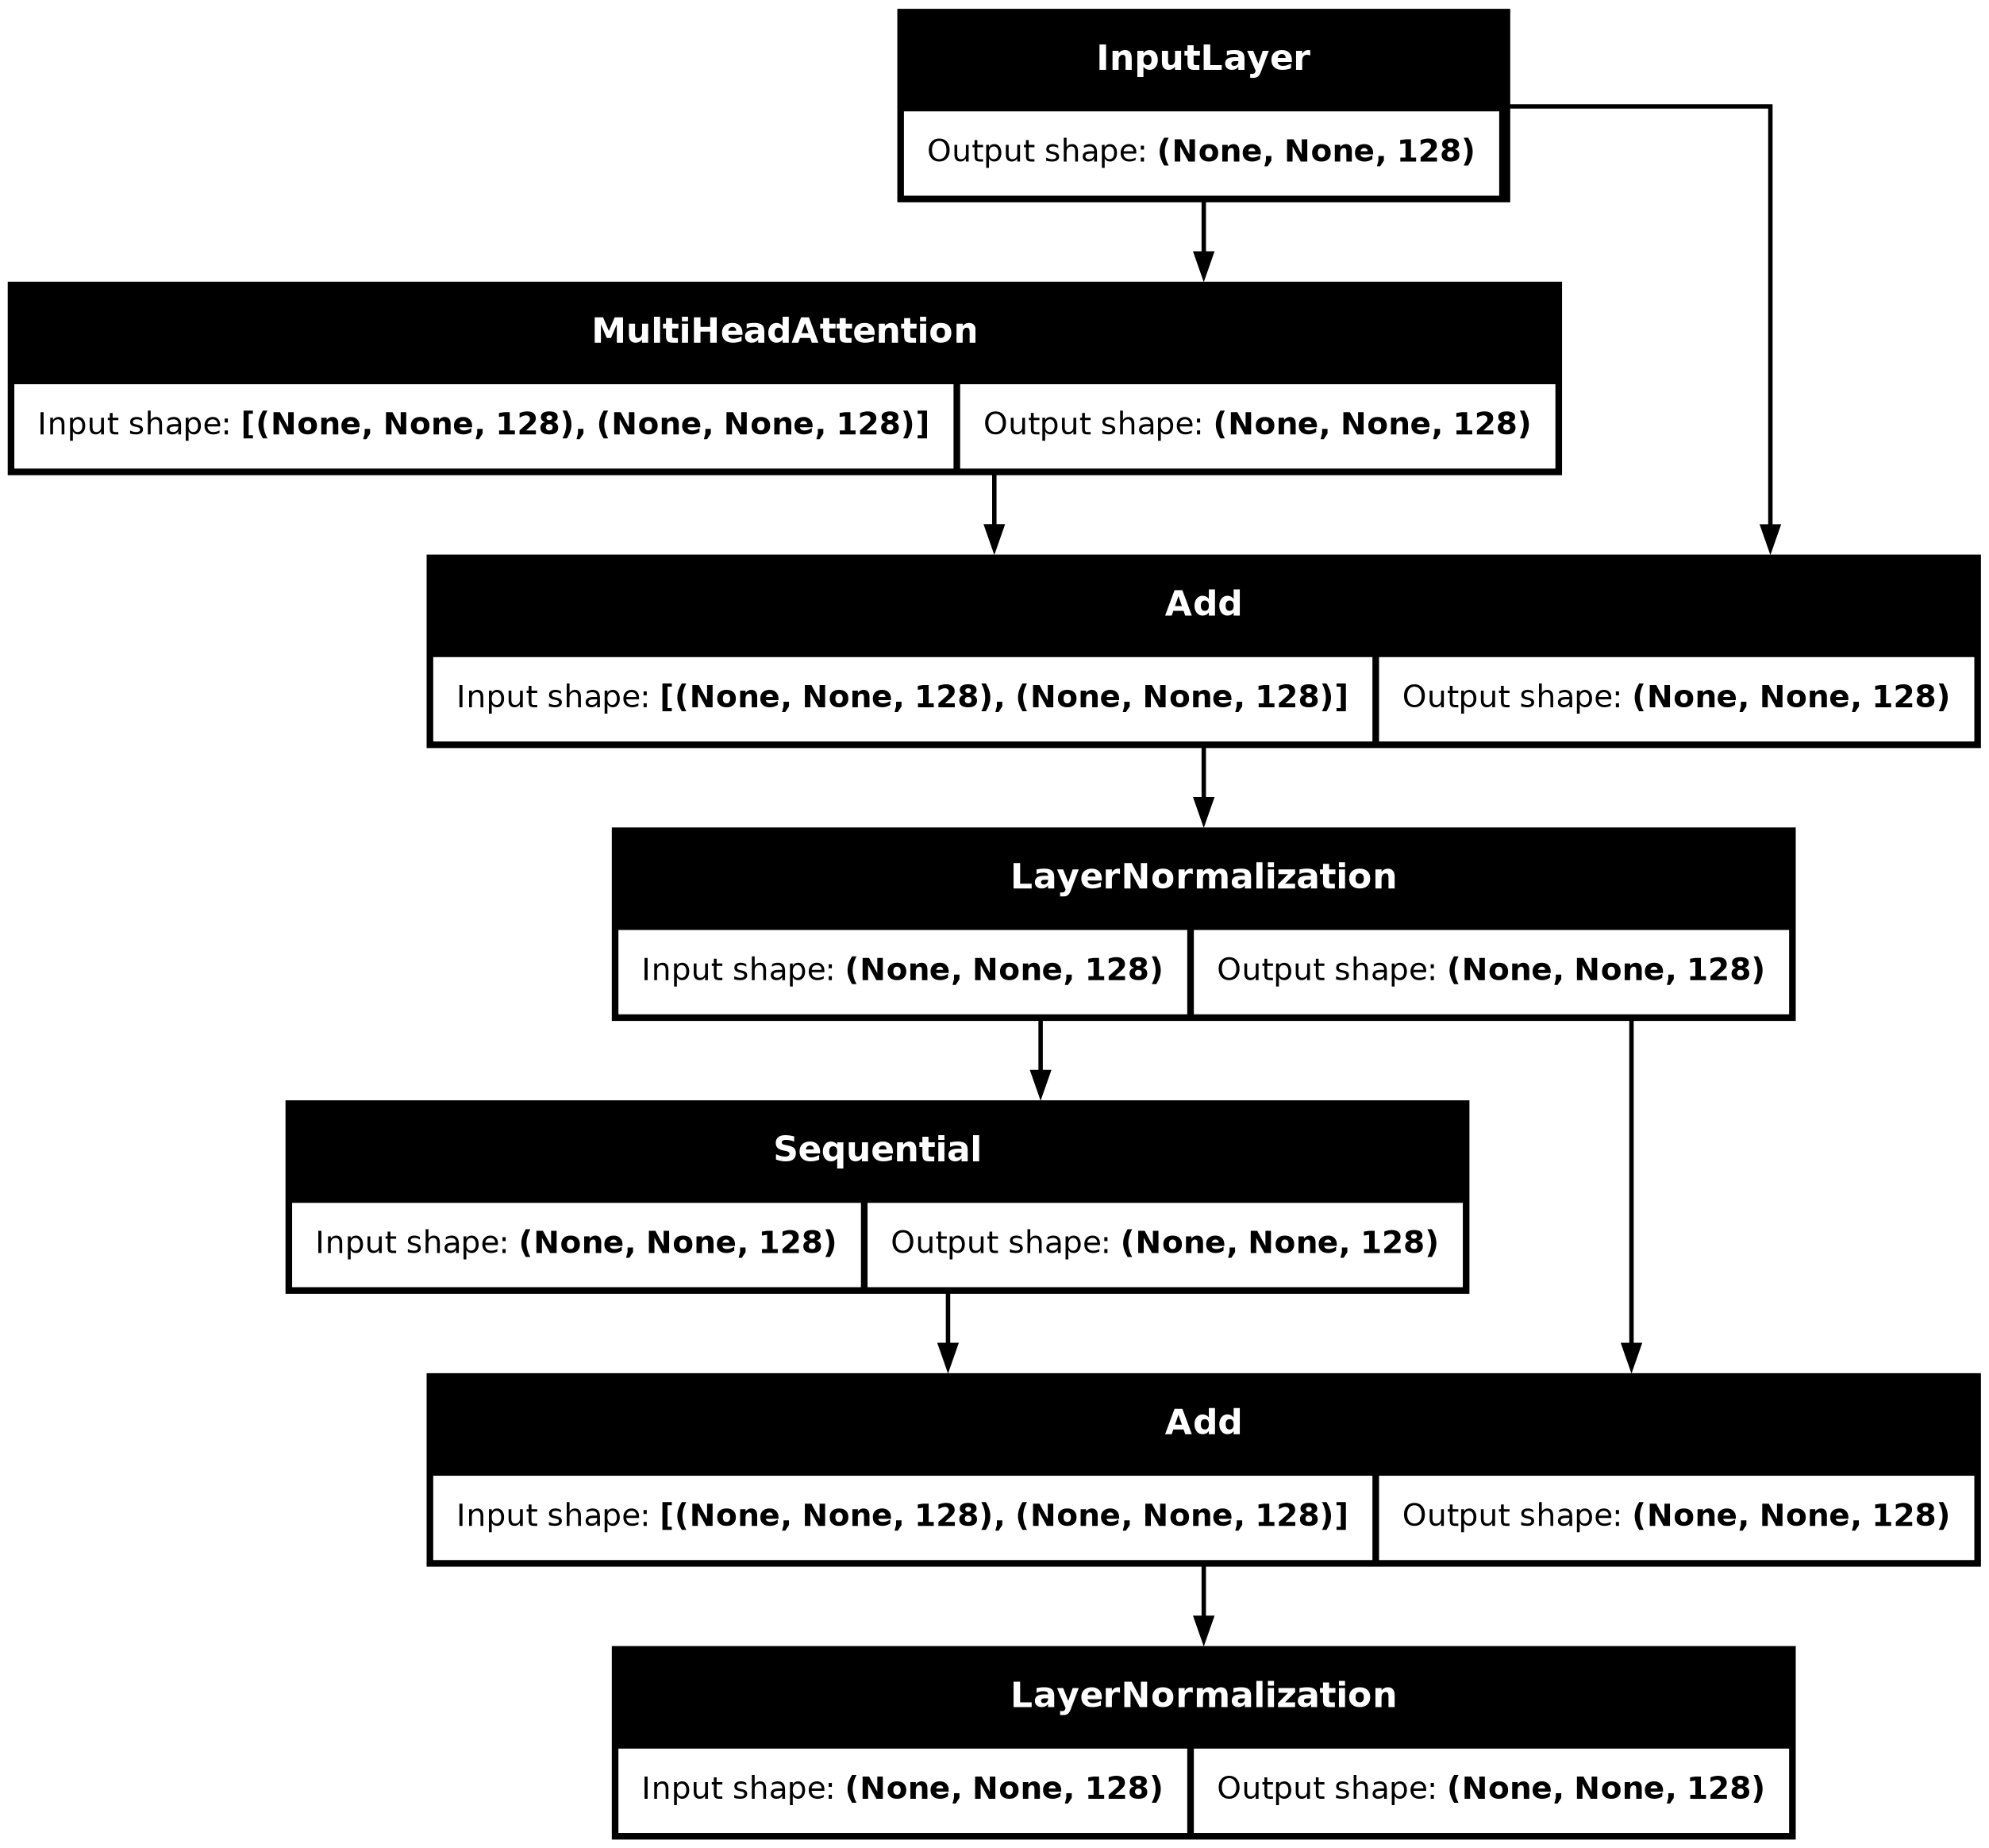

In [10]:
def get_encoder(inputs, embeding_demansion, mutil_head_cnt, potential_demansion):
    attention_layer = keras.layers.MultiHeadAttention(num_heads=mutil_head_cnt, 
                                                key_dim=embeding_demansion // mutil_head_cnt)

    mlp = keras.Sequential([
        keras.layers.Dense(potential_demansion, activation='relu'),
        keras.layers.Dense(embeding_demansion)
    ])

    # model create
    # 1. self attention
    x0 = inputs
    x = attention_layer(inputs, inputs)
    # 층 정규화
    x = keras.layers.LayerNormalization()(x+x0)

    # 2. MLP
    x0 = x
    x = mlp(x)
    # 층 정규화 
    x = keras.layers.LayerNormalization()(x+x0)
    model = keras.Model(inputs, x)
    return model 

inputs = keras.Input(shape=(None, 128)) # (배치 크기, 시퀀스 길이, 임베딩 차원)
encoder = get_encoder(inputs, embeding_demansion=128, mutil_head_cnt=4, potential_demansion=256)
encoder.summary()

keras.utils.plot_model(encoder, show_shapes=True)

In [8]:
import keras
from keras import layers

keras.backend.clear_session()

word_cnt = tokenize.get_piece_size()
print(f'어휘 수: {word_cnt:,}')
model = keras.Sequential([
    keras.Input(shape=(None,)), # 가변 길이 시퀀스 입력
    layers.Embedding(input_dim=word_cnt, output_dim=128), # 임베딩
    # TODO: 은닉층
    
    # 출력층
    layers.Dense(1, activation='sigmoid') # 이진 분류
])
model.summary()



어휘 수: 30,000


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 128)      │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 1)        │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,840,129 (14.65 MB)

 Trainable params: 3,840,129 (14.65 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['acc'],
)


#history = model.fit(
#    dataloaders['train'], epochs=10,
#    validation_data=dataloaders['validation'],
#    callbacks=[
#        keras.callbacks.ModelCheckpoint(
#            'text_classifier-transformer.keras', save_best_only=True)
#    ]
#)

Attention   

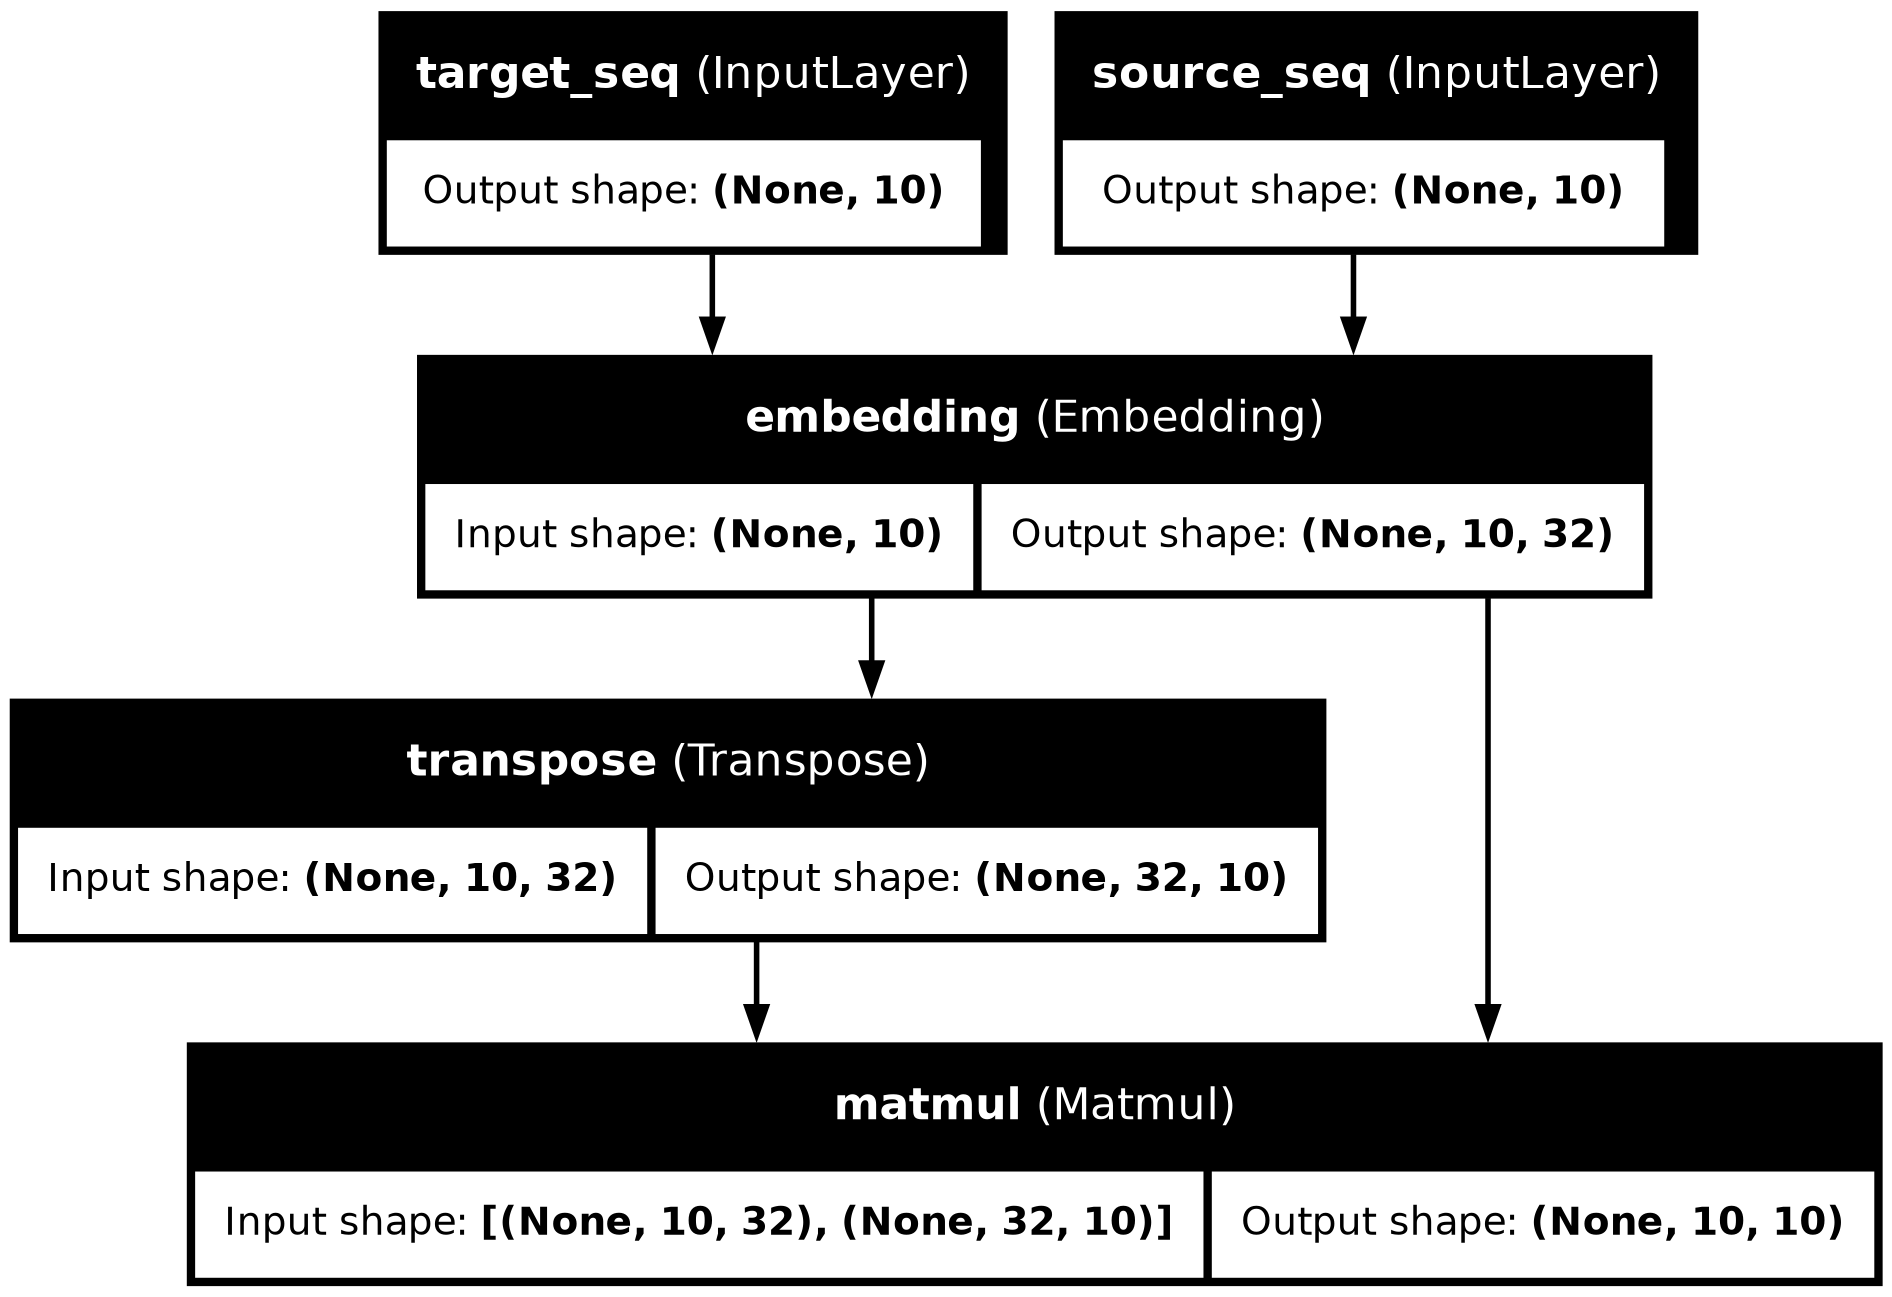

In [14]:
sequence_cnt = 10;
embedding_demansion = 32
word_cnt = 100

query = keras.Input(shape=(sequence_cnt, ), name='target_seq') # ex 번역 목표 문장
key = keras.Input(shape=(sequence_cnt, ), name='source_seq') # ex 번역 원문

embedding = layers.Embedding(input_dim=100, output_dim=embedding_demansion, name='embedding')

# 각 문장의 단어는 임베딩 차원 크기의 벡터로 변환됩니다. (배치 크기, 시퀀스 길이, 임베딩 차원)
Q = embedding(query) # (배치 크기, 시퀀스 길이, 임베딩 차원)
K = embedding(key) # (배치 크기, 시퀀스 길이, 임베딩 차원)

# Q와 K의 내적을 계산하여 어텐션 점수를 구합니다. QK^T
# 유사도 행렬이 됩니다.
KT = keras.ops.transpose(K, axes=(0,2,1)) # 

attension_score = keras.ops.matmul( Q, KT) # (배치 크기, 시퀀스 길이, 시퀀스 길이)

# keras.model 은 임의의 수학적 연산 
model = keras.Model(inputs=[query, key], outputs=attension_score)

# keras 가 pytorch보다 그림을 그려서 좋다. 
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)



In [15]:
query_seq = np.random.randint(0, word_cnt, size=(1, sequence_cnt))
key_seq = np.random.randint(0, word_cnt, size=(1, sequence_cnt))


display(pd.DataFrame({'query_seq': query_seq.flatten(), 'ket_seq': key_seq.flatten()}).T)

attention_score = model.predict([query_seq, key_seq])
attention_score = attention_score.squeeze() # 시퀀스길이, 시퀀스 길이 
print(f'att sorce: {attention_score.shape}')

display(pd.DataFrame(attention_score, index=query_seq.flatten(), columns=key_seq.flatten()).round(3))



,0,1,2,3,4,5,6,7,8,9
query_seq,21,15,21,66,28,7,54,62,23,49
ket_seq,70,20,43,76,23,15,55,27,47,39


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
att sorce: (10, 10)


,70,20,43,76,23,15,55,27,47,39
21,0.002,-0.002,-0.001,-0.000,-0.001,0.002,0.006,-0.004,-0.002,-0.005
15,0.002,-0.002,-0.005,-0.002,-0.003,0.023,0.002,-0.007,-0.006,0.003
21,0.002,-0.002,-0.001,-0.000,-0.001,0.002,0.006,-0.004,-0.002,-0.005
66,0.008,-0.000,0.005,-0.006,-0.003,-0.004,-0.005,-0.004,0.005,0.003
28,-0.005,0.010,-0.002,-0.009,-0.013,0.005,-0.000,-0.013,-0.003,-0.004
7,0.003,0.006,0.003,-0.007,-0.002,-0.006,0.002,0.006,0.000,-0.003
54,-0.004,0.007,-0.002,0.003,0.003,-0.001,-0.003,-0.002,-0.009,-0.004
62,-0.005,0.006,-0.001,-0.005,-0.012,-0.005,0.006,0.007,-0.000,0.000
23,0.002,-0.013,0.001,0.013,0.028,-0.003,-0.012,0.001,0.001,0.003
49,-0.002,-0.003,-0.002,0.004,-0.001,-0.004,0.001,-0.002,0.001,0.010


## self attention 
query = ke y 

In [16]:
# self attention 

query_seq = np.random.randint(0, word_cnt, size=(1, sequence_cnt))

display(pd.DataFrame({'query_seq': query_seq.flatten(), 'ket_seq': query_seq.flatten()}).T)

attention_score = model.predict([query_seq, query_seq])
attention_score = attention_score.squeeze() # 시퀀스길이, 시퀀스 길이 
print(f'att sorce: {attention_score.shape}')

display(pd.DataFrame(attention_score, index=query_seq.flatten(), columns=query_seq.flatten()).round(3))



,0,1,2,3,4,5,6,7,8,9
query_seq,18,39,15,10,99,1,95,37,86,89
ket_seq,18,39,15,10,99,1,95,37,86,89


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
att sorce: (10, 10)


,18,39,15,10,99,1,95,37,86,89
18,0.033,-0.003,0.001,0.004,-0.002,0.002,-0.004,-0.003,-0.005,0.009
39,-0.003,0.031,0.003,0.002,0.004,0.005,0.004,0.004,0.004,-0.008
15,0.001,0.003,0.023,0.001,0.003,0.002,-0.001,0.002,-0.000,0.005
10,0.004,0.002,0.001,0.026,0.003,0.003,-0.009,-0.001,0.002,0.001
99,-0.002,0.004,0.003,0.003,0.023,0.004,-0.002,-0.011,-0.000,-0.000
1,0.002,0.005,0.002,0.003,0.004,0.022,0.003,0.005,-0.001,-0.005
95,-0.004,0.004,-0.001,-0.009,-0.002,0.003,0.033,0.009,-0.005,-0.009
37,-0.003,0.004,0.002,-0.001,-0.011,0.005,0.009,0.026,0.003,-0.007
86,-0.005,0.004,-0.000,0.002,-0.000,-0.001,-0.005,0.003,0.030,-0.011
89,0.009,-0.008,0.005,0.001,-0.000,-0.005,-0.009,-0.007,-0.011,0.037


### 첨부파일 mini chat_gpt 구현 - train_gpt.py

## multi head attention 
- 128 차원을 한꺼번에 하려고 하다보니 힘들어서 각 차원 별로쪼개서 학습 ( 각차원 = 학습의 단위 (관심사))

In [18]:
from keras import layers

query_seq = np.random.randint(0, word_cnt, size=(1, sequence_cnt))
key_seq = np.random.randint(0, word_cnt, size=(1, sequence_cnt))


display(pd.DataFrame({'query_seq': query_seq.flatten(), 'ket_seq': key_seq.flatten()}).T)

embedding_demansion = 128
word_cnt = 100
multi_head_cnt = 4

embedding = keras.layers.Embedding(
    input_dim=word_cnt, output_dim=embedding_demansion, name='embedding'
)

# 각 문장의 단어는 임베딩 차원 크기의 벡터로 변환됩니다. (배치 크기, 시퀀스 길이, 임베딩 차원)
Q = embedding(query) # (배치 크기, 시퀀스 길이, 임베딩 차원)
K = embedding(key) # (배치 크기, 시퀀스 길이, 임베딩 차원)

# multi head
head_projections = [keras.layers.Dense(embedding_demansion // multi_head_cnt) for _ in range(multi_head_cnt)]
heads = []

for i in range(multi_head_cnt):
    Qi = head_projections[i](Q) # batch size, sequence size, embedding // multi head cnt
    Ki = head_projections[i](K)

    KTi = keras.ops.transpose(Ki, axes=(0,2,1)) # batch size, embedding // multi head cnt, sequence size,
    attention_score_i = keras.ops.matmul( Qi, KTi) # (배치 크기, 시퀀스 길이, 시퀀스 길이)
    heads.append(attention_score_i)




,0,1,2,3,4,5,6,7,8,9
query_seq,62,80,52,53,24,23,27,76,30,49
ket_seq,53,52,96,21,38,34,50,60,46,53


In [20]:
multi_head_attention = keras.layers.MultiHeadAttention(num_heads=multi_head_cnt, key_dim=embedding_demansion // multi_head_cnt)
xq = embedding(query_seq)
xk = embedding(key_seq)
output_attention = multi_head_attention(query=xq, value=xk,key=xk)

## 텍스트 분류 트랜스포머 

In [21]:
import keras
from keras import layers
# transformer.py 파일에서 TransformerEncoder 클래스를 가져옵니다.
from transformer_me import TransformerEncoder

keras.backend.clear_session()

def build_model(어휘수, 임베딩차원, 멀티헤드수, 잠재차원):
    model = keras.Sequential([
        keras.Input(shape=(None,)), # 가변 길이 시퀀스 입력
        layers.Embedding(input_dim=어휘수, output_dim=임베딩차원, mask_zero=True), # 임베딩
        # 은닉층
        TransformerEncoder(embed_dim=임베딩차원, num_heads=멀티헤드수, dense_dim=잠재차원),
        # 출력층
        layers.GlobalAveragePooling1D(), # 벡터화
        layers.Dense(1, activation='sigmoid') # 이진 분류
    ])
    return model

model = build_model(어휘수=30000, 임베딩차원=128, 멀티헤드수=4, 잠재차원=256)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 128)      │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, None, 128)      │       330,240 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,170,369 (15.91 MB)

 Trainable params: 4,170,369 (15.91 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
%run load_text_class_example_me.py

model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['acc'],
)

history = model.fit(
    dataloaders['train'], epochs=10,
    validation_data=dataloaders['validation'],
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            'text_classifier-transformer.keras', save_best_only=True)
    ]
)

train     : 20,000
validation: 2,000
test      : 2,000
train      배치 수: 625
validation 배치 수: 63
test       배치 수: 63
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - acc: 0.9495 - loss: 0.1015 - val_acc: 0.9930 - val_loss: 0.0256
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - acc: 0.9991 - loss: 0.0029 - val_acc: 0.9885 - val_loss: 0.0406
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - acc: 1.0000 - loss: 1.4065e-04 - val_acc: 0.9915 - val_loss: 0.0429
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - acc: 1.0000 - loss: 6.6145e-06 - val_acc: 0.9895 - val_loss: 0.0490
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - acc: 1.0000 - loss: 3.5584e-06 - val_acc: 0.9890 - val_loss: 0.0530
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - acc: 1.0000 - loss: 2.2633e-06 - val_acc: 0.9885 - val_loss: 0.0566
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - acc: 1.0000 - loss: 1.6395e-06 - val_acc: 0.9885 - val_loss: 0.0602
Epoch 8/10
625/625 ━━━━━

## Encoder Docoder
- add & norm 0 == Dense # Dense  기바반이되는 신경망
- 



### GPT 2 SKT 모델 https://huggingface.co/skt/kogpt2-base-v2

- (wte): Embedding(51200, 768)
  (wpe): Embedding(1024, 768)
    => # (wte): Embedding(51200, 768) , 5만개의 어휘, 768차원 , (wpe): Embedding(1024, 768) 1024개의 단어 순서 
- attention은 사용
- (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768) # dense 대신 사용함 왜?
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
- (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  => 768 차원에서 의 결과물 = x' , x' = x + pos + context 
- Linear(in_features=768, out_features=51200, bias=False) # 5만의 종류 중에 결과물 추출 
  

In [2]:
import transformers # huggin face transformers lib


In [3]:
from transformers import GPT2LMHeadModel # SKT 에서 제공한 2021 년 모델입니다. 

model = GPT2LMHeadModel.from_pretrained('/workspace/kogpt2')

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: /workspace/kogpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
print(model) # (wte): Embedding(51200, 768) , 5만개의 어휘, 768차원 , (wpe): Embedding(1024, 768) 1024개의 단어 순서 

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(51200, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=51200, bias=False)
)


In [8]:
from transformers import PreTrainedTokenizerFast

tokenizer = PreTrainedTokenizerFast.from_pretrained("skt/kogpt2-base-v2",
  bos_token='</s>', eos_token='</s>', unk_token='<unk>',
  pad_token='<pad>', mask_token='<mask>')

tokenizer.tokenize("안녕하세요. 한국어 GPT-2 입니다.😤:)l^o")





['▁안녕',
 '하',
 '세',
 '요.',
 '▁한국어',
 '▁G',
 'P',
 'T',
 '-2',
 '▁입',
 '니다.',
 '😤',
 ':)',
 'l^o']

In [ ]:
# skt sample

prompt = '근육이 커지기 위해서는'
input_token = tokenizer.encode(prompt, return_tensors='pt')

pd.DataFrame({
    'token': tokenizer.tokenize(prompt),
    'int_sequence': input_token.flatten().tolist()
}).T



with torch.inference_mode():
    output_token = model.generate(
        input_token, 
        max_new_tokens=128, # 종료 시그널 1 - 최대 문장 수 
        repetition_penalty=2.0, # 종료 시그널 2 반복 패널티를 주는것 value = 2 강한 제제
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id, # 종료 시그널 3 - end of signal
        bos_token_id=tokenizer.bos_token_id,
        )

# 정수 시퀀스 디코딩 : 정수 ID 를 텍스트 토큰 변환 후 문자열 병합
output_sentence = tokenizer.decode(output_token[0], skip_special_tokens=True)
print(output_sentence) # 자신이 다음을 예측한 것을 또 다시 자기 자신이 예측해야될 메인 prompt가 된다 auto regressive 



근육이 커지기 위해서는 무엇보다 규칙적인 생활습관이 중요하다.
특히, 아침식사는 단백질과 비타민이 풍부한 과일과 채소를 많이 섭취하는 것이 좋다.
또한 하루 30분 이상 충분한 수면을 취하는 것도 도움이 된다.
아침 식사를 거르지 않고 규칙적으로 운동을 하면 혈액순환에 도움을 줄 뿐만 아니라 신진대사를 촉진해 체내 노폐물을 배출하고 혈압을 낮춰준다.
운동은 하루에 10분 정도만 하는 게 좋으며 운동 후에는 반드시 스트레칭을 통해 근육량을 늘리고 유연성을 높여야 한다.
운동 후 바로 잠자리에 드는 것은 피해야 하며 특히 아침에 일어나면 몸이 피곤해지기 때문에 무리하게 움직이면 오히려 역효과가 날 수도 있다.
운동을 할 때는 몸을 따뜻하게


In [22]:
prompt = '나는 너를 사랑하는데, 너도 나를'
input_token = tokenizer.encode(prompt, return_tensors='pt')

# 존재하는 token인지 확인 
pd.DataFrame({
    'token': tokenizer.tokenize(prompt),
    'int_sequence': input_token.flatten().tolist()
}).T

# 직접 분석을 위해 model에 시퀀스를 춘다. 
with torch.inference_mode():
    output_sentence = model(input_token)

print(type(output_sentence))
print(output_sentence.keys())
print(output_sentence.logits.shape) # 배치크기, 시퀀스 길이 어휘 루 


<class 'transformers.modeling_outputs.CausalLMOutputWithCrossAttentions'>
odict_keys(['logits', 'past_key_values'])
torch.Size([1, 7, 51200])
